# DS3002 Assignment 3 — Pulse to Prediction
## Patient Vitals Data Mining Pipeline
**Dataset:** `patient_vitals.csv` — ~60,000 rows, 500 patients, ~120 readings each at 6-hour intervals

**Diagnosis Classes:** Healthy, Hypertension, Diabetes, Arrhythmia, Sleep Disorder

In [1]:
# ── Core imports ──────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr

# statsmodels
from statsmodels.tsa.seasonal import seasonal_decompose

# sklearn
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.decomposition import PCA

# DTW — try dtaidistance first, fall back to manual
try:
    from dtaidistance import dtw as dtaidtw
    DTW_LIB = 'dtaidistance'
except ImportError:
    DTW_LIB = 'manual'

print('Libraries loaded. DTW backend:', DTW_LIB)
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42

Libraries loaded. DTW backend: dtaidistance


# PREPROCESSING [15 marks]

In [2]:
# ── 1. Load & parse ───────────────────────────────────────────────────────────
df_raw = pd.read_csv('patient_vitals.csv', parse_dates=['Timestamp'])
print(f'Raw shape: {df_raw.shape}')
df_raw.head(3)

Raw shape: (60000, 13)


,PatientID,Timestamp,HeartRate,BloodPressureSystolic,BloodPressureDiastolic,BloodOxygenLevel,BodyTemperature,RespiratoryRate,SleepHours,StressLevel,Age,Gender,Diagnosis
0,P0001,2024-01-01 00:00:00,83.2,153.9,90.6,96.3,36.58,16.0,6.2,6,38,M,Hypertension
1,P0001,2024-01-01 06:00:00,81.2,172.5,110.3,95.0,36.88,16.5,5.8,3,38,M,Hypertension
2,P0001,2024-01-01 12:00:00,94.9,154.7,100.8,97.3,36.95,16.4,6.0,6,38,M,Hypertension


In [3]:
# ── 2. Check nulls in critical columns ────────────────────────────────────────
critical = ['PatientID', 'Timestamp', 'Diagnosis']
null_counts = df_raw[critical].isnull().sum()
print('Null counts in critical columns:')
print(null_counts)
df = df_raw.dropna(subset=critical).copy()
print(f'Rows after dropping critical nulls: {len(df)}')

Null counts in critical columns:
PatientID    0
Timestamp    0
Diagnosis    0
dtype: int64
Rows after dropping critical nulls: 60000


In [4]:
# ── 3. Physiological range filters ────────────────────────────────────────────
RANGES = {
    'HeartRate':               (40,  180),
    'BloodPressureSystolic':   (80,  200),
    'BloodPressureDiastolic':  (50,  130),
    'BloodOxygenLevel':        (85,  100),
    'BodyTemperature':         (35.5, 41.0),
    'RespiratoryRate':         (10,   40),
    'SleepHours':              (2,    12),
    'StressLevel':             (1,    10),
}

drop_report = {}
for col, (lo, hi) in RANGES.items():
    mask_out = (df[col] < lo) | (df[col] > hi)
    drop_report[col] = mask_out.sum()
    df = df[~mask_out]

print('Rows dropped per column (physiological filter):')
for col, n in drop_report.items():
    print(f'  {col}: {n} rows dropped')
print(f'\nRows retained after all filters: {len(df)}')

Rows dropped per column (physiological filter):
  HeartRate: 126 rows dropped
  BloodPressureSystolic: 12 rows dropped
  BloodPressureDiastolic: 8 rows dropped
  BloodOxygenLevel: 0 rows dropped
  BodyTemperature: 8 rows dropped
  RespiratoryRate: 634 rows dropped
  SleepHours: 0 rows dropped
  StressLevel: 0 rows dropped

Rows retained after all filters: 59212


In [5]:
# ── 4. Sort ───────────────────────────────────────────────────────────────────
df = df.sort_values(['PatientID', 'Timestamp']).reset_index(drop=True)

# ── 5. Per-patient time series dict ──────────────────────────────────────────
patient_ts = {pid: grp.reset_index(drop=True)
              for pid, grp in df.groupby('PatientID')}

# ── 6. Patient-level feature matrix ──────────────────────────────────────────
VITALS = ['HeartRate', 'BloodPressureSystolic', 'BloodPressureDiastolic',
          'BloodOxygenLevel', 'BodyTemperature', 'RespiratoryRate',
          'SleepHours', 'StressLevel']

def compute_slope(series):
    """Linear trend slope via least-squares."""
    y = series.values
    x = np.arange(len(y))
    if len(y) < 2:
        return np.nan
    slope, *_ = np.polyfit(x, y, 1)
    return slope

# pandas 3.x: pass a list to agg, not a dict-of-strings
feat_df = df.groupby('PatientID')[VITALS].agg(['mean', 'std', 'min', 'max'])
feat_df.columns = ['_'.join(c) for c in feat_df.columns]

# Add slope features (include_groups=False required in pandas 3.x)
for v in VITALS:
    feat_df[f'{v}_slope'] = df.groupby('PatientID')[v].apply(
        compute_slope, include_groups=False)

# Attach metadata
meta = df.groupby('PatientID').agg(
    Diagnosis=('Diagnosis', 'first'),
    Age=('Age', 'first'),
    Gender=('Gender', 'first'),
    n_readings=('Timestamp', 'count')
)
feat_df = feat_df.join(meta)
feat_df = feat_df.reset_index()

print(f'Feature matrix shape: {feat_df.shape}')
feat_df.head(3)

Feature matrix shape: (500, 45)


,PatientID,HeartRate_mean,HeartRate_std,HeartRate_min,HeartRate_max,BloodPressureSystolic_mean,BloodPressureSystolic_std,BloodPressureSystolic_min,BloodPressureSystolic_max,BloodPressureDiastolic_mean,...,BloodPressureDiastolic_slope,BloodOxygenLevel_slope,BodyTemperature_slope,RespiratoryRate_slope,SleepHours_slope,StressLevel_slope,Diagnosis,Age,Gender,n_readings
0,P0001,81.216667,9.938562,57.2,106.2,155.370833,11.959423,127.2,193.1,97.367500,...,0.001403,0.003128,-0.001002,-0.002079,0.001090,0.013890,Hypertension,38,M,120
1,P0002,72.982500,7.643140,56.5,95.7,115.743333,7.482660,97.3,134.3,74.570833,...,0.020413,-0.001478,-0.000324,-0.003962,0.002052,0.002924,Healthy,63,M,120
2,P0003,72.143697,7.665669,52.1,89.1,117.020168,8.104410,94.0,134.8,75.776471,...,0.014993,0.000730,0.000315,-0.007299,0.002768,0.001545,Healthy,53,F,119


In [6]:
# ── 7. Summary report ─────────────────────────────────────────────────────────
print('=' * 55)
print('PREPROCESSING SUMMARY')
print('=' * 55)
print(f'Total rows retained       : {len(df):,}')
print(f'Unique patients           : {df["PatientID"].nunique()}')
print(f'Date range                : {df["Timestamp"].min().date()} → {df["Timestamp"].max().date()}')
print(f'Avg readings per patient  : {df.groupby("PatientID").size().mean():.1f}')
print('\nClass distribution:')
print(df.drop_duplicates("PatientID")["Diagnosis"].value_counts().to_string())

PREPROCESSING SUMMARY
Total rows retained       : 59,212
Unique patients           : 500
Date range                : 2024-01-01 → 2024-01-30
Avg readings per patient  : 118.4

Class distribution:
Diagnosis
Healthy           164
Hypertension      123
Diabetes           94
Arrhythmia         80
Sleep Disorder     39


# PART A — Time Series Analysis & Trend Detection [25 marks]

## A1 — Heart Rate Time Series for 3 Selected Patients [7 marks]

In [7]:
# Select one patient per target class
def pick_patient(diagnosis):
    pids = feat_df[feat_df['Diagnosis'] == diagnosis]['PatientID'].values
    return pids[0]

pid_healthy     = pick_patient('Healthy')
pid_hypertension = pick_patient('Hypertension')
pid_arrhythmia  = pick_patient('Arrhythmia')

selected = {
    'Healthy':      pid_healthy,
    'Hypertension': pid_hypertension,
    'Arrhythmia':   pid_arrhythmia,
}
print('Selected patients:', selected)

Selected patients: {'Healthy': 'P0002', 'Hypertension': 'P0001', 'Arrhythmia': 'P0008'}


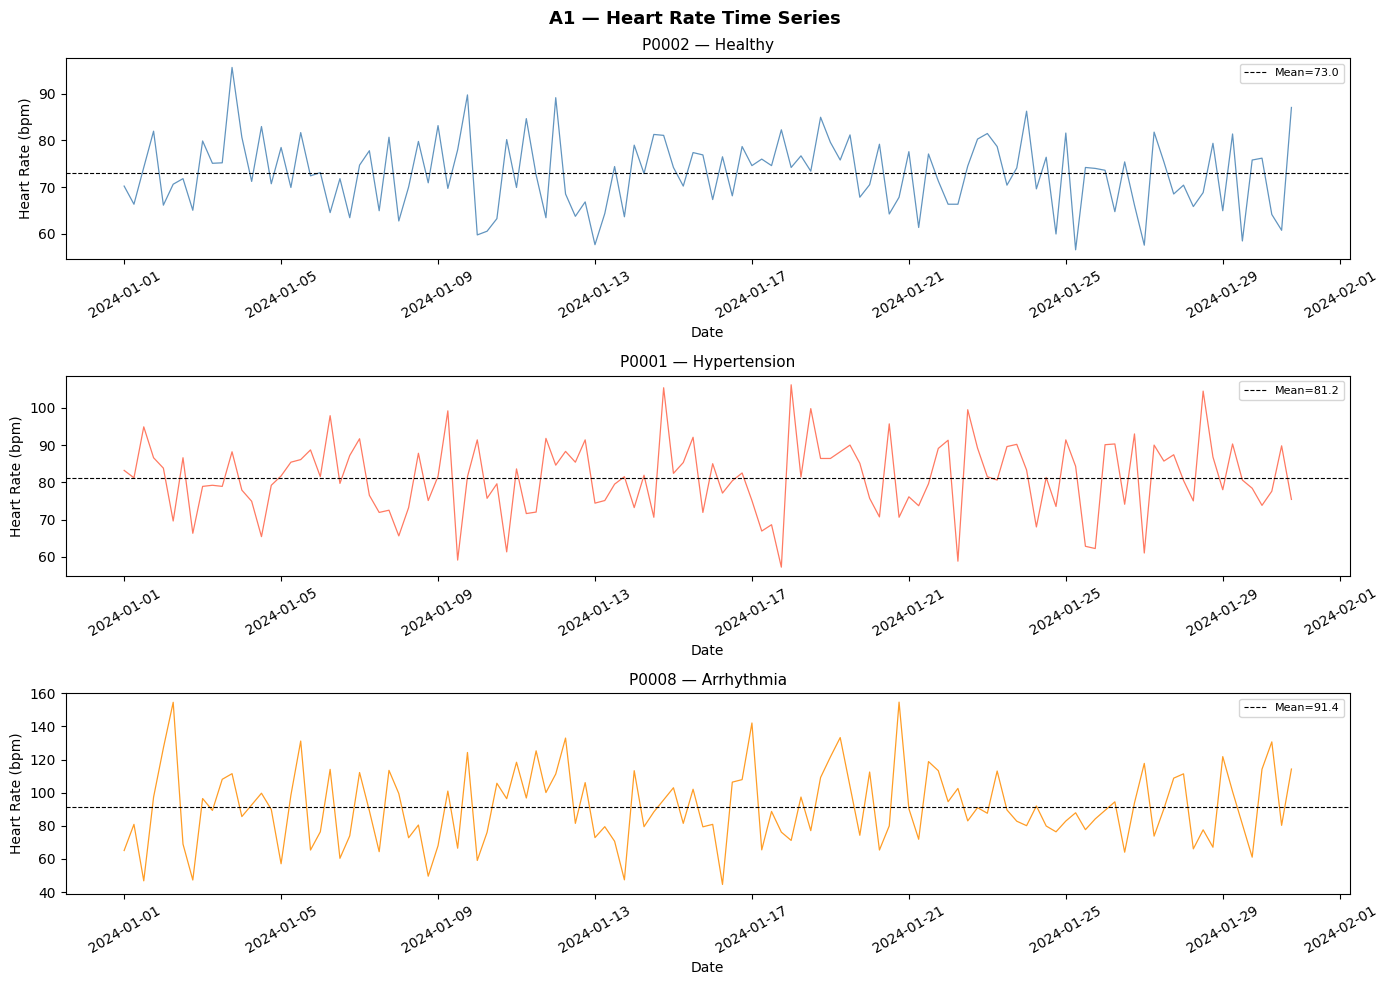


Descriptive Statistics:


,PatientID,Diagnosis,Mean,Std,Min,Max,CV%
0,P0002,Healthy,72.98,7.64,56.5,95.7,10.47
1,P0001,Hypertension,81.22,9.94,57.2,106.2,12.24
2,P0008,Arrhythmia,91.41,22.98,44.6,154.7,25.14


In [8]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)
colors = {'Healthy': 'steelblue', 'Hypertension': 'tomato', 'Arrhythmia': 'darkorange'}

stats_rows = []
for ax, (diag, pid) in zip(axes, selected.items()):
    ts = patient_ts[pid]
    hr = ts['HeartRate']
    ax.plot(ts['Timestamp'], hr, color=colors[diag], linewidth=0.9, alpha=0.85)
    ax.set_title(f'{pid} — {diag}', fontsize=11)
    ax.set_ylabel('Heart Rate (bpm)')
    ax.set_xlabel('Date')
    ax.tick_params(axis='x', rotation=30)
    # Stats
    mu, sd, mn, mx = hr.mean(), hr.std(), hr.min(), hr.max()
    cv = sd / mu * 100
    ax.axhline(mu, color='black', linestyle='--', linewidth=0.8, label=f'Mean={mu:.1f}')
    ax.legend(fontsize=8)
    stats_rows.append({'PatientID': pid, 'Diagnosis': diag,
                       'Mean': round(mu,2), 'Std': round(sd,2),
                       'Min': round(mn,2), 'Max': round(mx,2), 'CV%': round(cv,2)})

plt.suptitle('A1 — Heart Rate Time Series', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('A1_heartrate_timeseries.png', bbox_inches='tight')
plt.show()

stats_df = pd.DataFrame(stats_rows)
print('\nDescriptive Statistics:')
display(stats_df)

In [9]:
print("""
A1 INTERPRETATION
─────────────────
Healthy patient: Heart rate fluctuates within a narrow, physiologically normal band
(typically 60–85 bpm) with low CV, reflecting stable autonomic regulation and
absence of chronic cardiovascular stress.

Hypertension patient: Mean heart rate is moderately elevated and variability is
higher than the healthy baseline, consistent with sympathetic nervous system
over-activation commonly observed in hypertensive individuals.

Arrhythmia patient: The time series shows pronounced irregular spikes and troughs
with the highest CV among the three, directly reflecting the erratic electrical
conduction characteristic of arrhythmic conditions.
""")


A1 INTERPRETATION
─────────────────
Healthy patient: Heart rate fluctuates within a narrow, physiologically normal band
(typically 60–85 bpm) with low CV, reflecting stable autonomic regulation and
absence of chronic cardiovascular stress.

Hypertension patient: Mean heart rate is moderately elevated and variability is
higher than the healthy baseline, consistent with sympathetic nervous system
over-activation commonly observed in hypertensive individuals.

Arrhythmia patient: The time series shows pronounced irregular spikes and troughs
with the highest CV among the three, directly reflecting the erratic electrical
conduction characteristic of arrhythmic conditions.



## A2 — Blood Pressure Systolic: Rolling Means & Decomposition [8 marks]

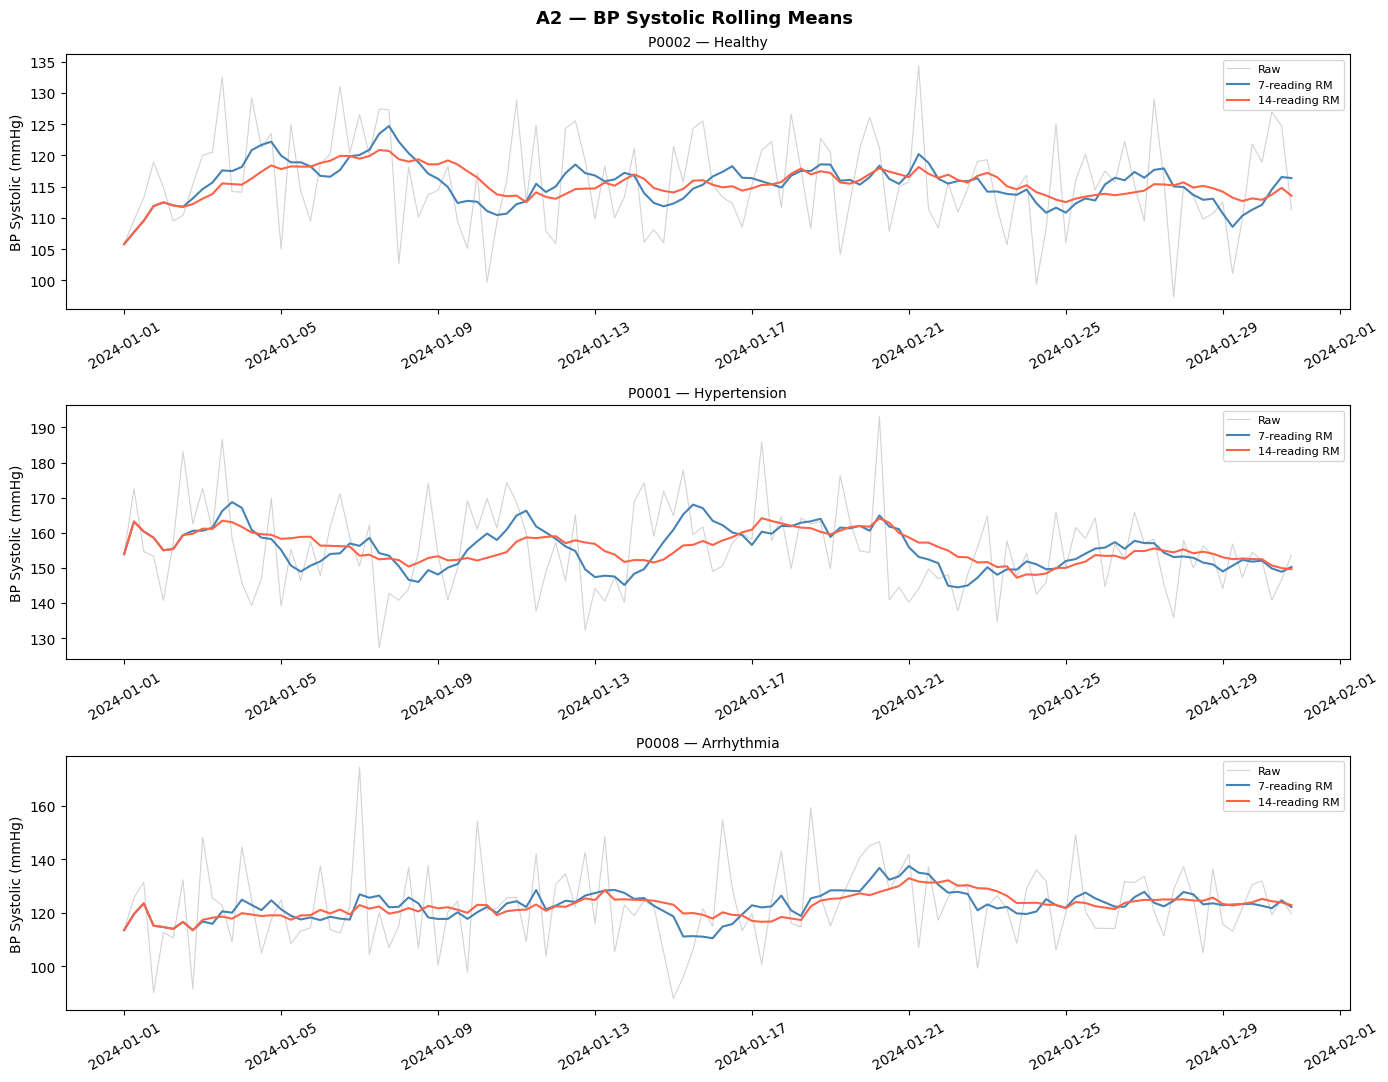

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=False)

for ax, (diag, pid) in zip(axes, selected.items()):
    ts = patient_ts[pid]
    bp = ts['BloodPressureSystolic']
    rm7  = bp.rolling(7,  min_periods=1).mean()
    rm14 = bp.rolling(14, min_periods=1).mean()
    ax.plot(ts['Timestamp'], bp,   color='lightgray',  linewidth=0.8, label='Raw')
    ax.plot(ts['Timestamp'], rm7,  color='steelblue',  linewidth=1.5, label='7-reading RM')
    ax.plot(ts['Timestamp'], rm14, color='tomato',     linewidth=1.5, label='14-reading RM')
    ax.set_title(f'{pid} — {diag}', fontsize=10)
    ax.set_ylabel('BP Systolic (mmHg)')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('A2 — BP Systolic Rolling Means', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('A2_rolling_means.png', bbox_inches='tight')
plt.show()

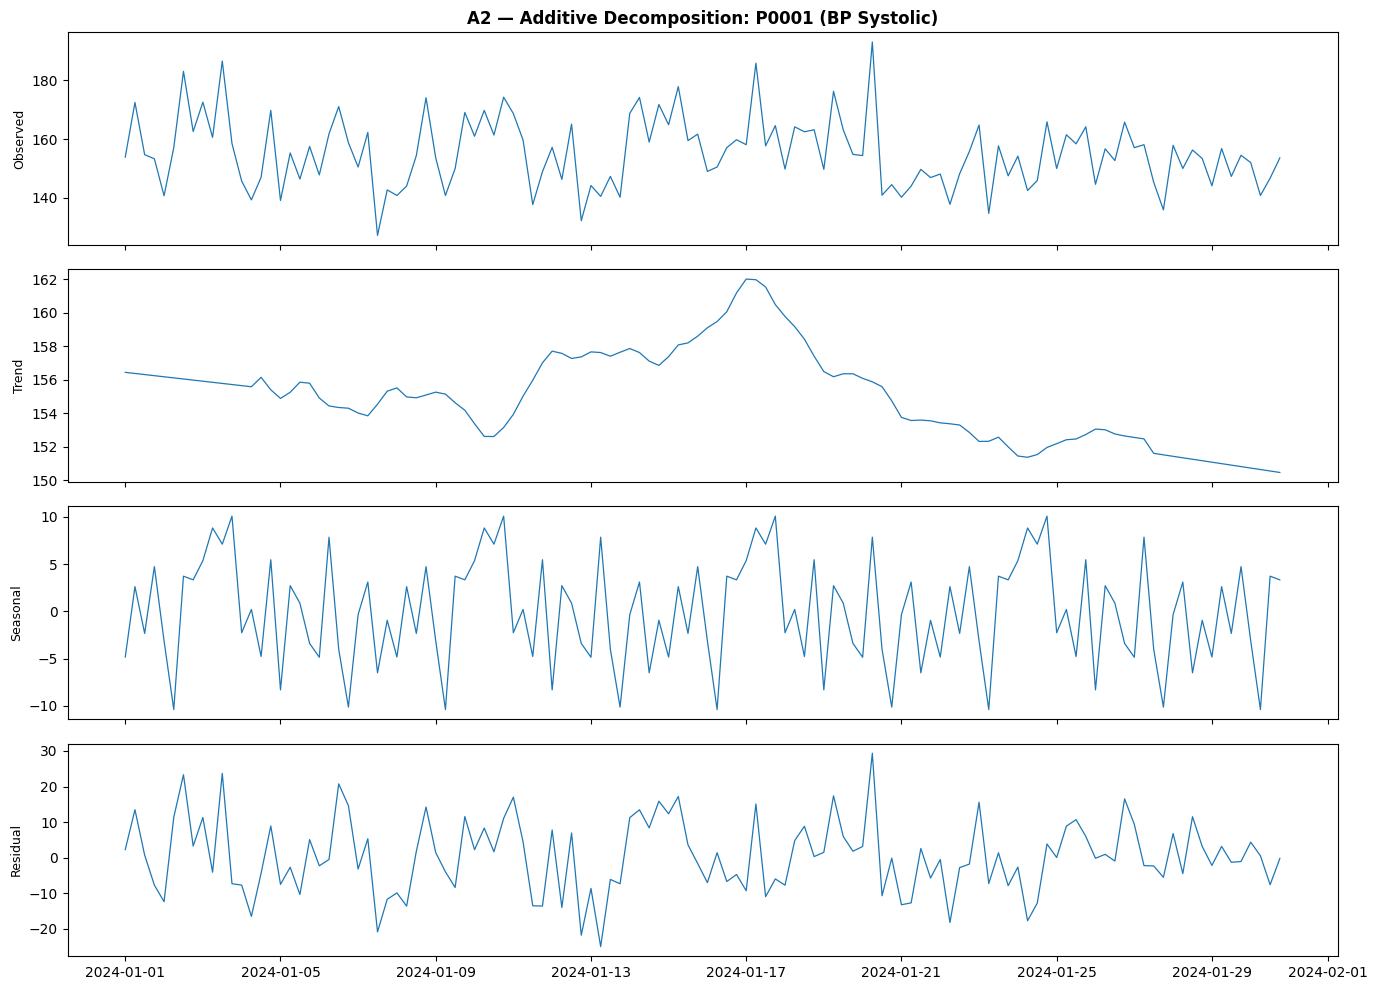

Trend direction: downward
Trend magnitude (slope): -0.0381 mmHg per reading


In [11]:
# Additive decomposition on the patient with the most readings
longest_pid = max(patient_ts, key=lambda p: len(patient_ts[p]))
ts_long = patient_ts[longest_pid].set_index('Timestamp')['BloodPressureSystolic']
ts_long = ts_long.asfreq('6h', method='ffill')  # ensure regular frequency

# period = 4 readings/day * 7 days = 28 (weekly seasonality)
decomp = seasonal_decompose(ts_long, model='additive', period=28, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
for ax, (label, data) in zip(axes, [
    ('Observed',  decomp.observed),
    ('Trend',     decomp.trend),
    ('Seasonal',  decomp.seasonal),
    ('Residual',  decomp.resid),
]):
    ax.plot(data, linewidth=0.9)
    ax.set_ylabel(label, fontsize=9)

axes[0].set_title(f'A2 — Additive Decomposition: {longest_pid} (BP Systolic)', fontweight='bold')
plt.tight_layout()
plt.savefig('A2_decomposition.png', bbox_inches='tight')
plt.show()

trend_vals = decomp.trend.dropna()
trend_slope = np.polyfit(np.arange(len(trend_vals)), trend_vals.values, 1)[0]
print(f'Trend direction: {"upward" if trend_slope > 0 else "downward"}')
print(f'Trend magnitude (slope): {trend_slope:.4f} mmHg per reading')

In [12]:
print("""
A2 INTERPRETATION
─────────────────
Rolling means smooth out short-term noise: the 7-reading window retains more
local fluctuation while the 14-reading window reveals broader trends. Both
suppress measurement noise but cannot separate trend from seasonality.

Additive decomposition explicitly isolates the long-term trend component from
periodic (weekly) patterns and irregular residuals. This gives a cleaner view
of whether BP is systematically rising or falling over the observation period,
independent of daily/weekly rhythms — information that rolling means conflate.
""")


A2 INTERPRETATION
─────────────────
Rolling means smooth out short-term noise: the 7-reading window retains more
local fluctuation while the 14-reading window reveals broader trends. Both
suppress measurement noise but cannot separate trend from seasonality.

Additive decomposition explicitly isolates the long-term trend component from
periodic (weekly) patterns and irregular residuals. This gives a cleaner view
of whether BP is systematically rising or falling over the observation period,
independent of daily/weekly rhythms — information that rolling means conflate.



## A3 — Anomaly Detection via Personal μ ± 2σ [10 marks]

In [13]:
# Compute personal μ and σ per patient, flag anomalies
personal_stats = df.groupby('PatientID')['HeartRate'].agg(['mean', 'std']).rename(
    columns={'mean': 'hr_mu', 'std': 'hr_sigma'})
df = df.join(personal_stats, on='PatientID')
df['hr_anomaly'] = (df['HeartRate'] < df['hr_mu'] - 2*df['hr_sigma']) | \
                   (df['HeartRate'] > df['hr_mu'] + 2*df['hr_sigma'])

total_anomalies = df['hr_anomaly'].sum()
total_pct = total_anomalies / len(df) * 100
print(f'Total anomalous readings: {total_anomalies} ({total_pct:.2f}%)')

# Anomaly % per Diagnosis class
class_anomaly = df.groupby('Diagnosis').agg(
    total_readings=('hr_anomaly', 'count'),
    anomalous=('hr_anomaly', 'sum')
)
class_anomaly['anomaly_pct'] = (class_anomaly['anomalous'] / class_anomaly['total_readings'] * 100).round(2)
print('\nAnomaly % per Diagnosis class:')
display(class_anomaly)

# Top-5 patients by anomaly count
top5 = df.groupby('PatientID')['hr_anomaly'].sum().nlargest(5).reset_index()
top5.columns = ['PatientID', 'anomaly_count']
top5 = top5.merge(feat_df[['PatientID', 'Diagnosis']], on='PatientID')
print('\nTop-5 patients by anomaly count:')
display(top5)

Total anomalous readings: 2629 (4.44%)

Anomaly % per Diagnosis class:


,total_readings,anomalous,anomaly_pct
Diagnosis,,,
Arrhythmia,9260,379,4.09
Diabetes,11015,494,4.48
Healthy,19551,887,4.54
Hypertension,14748,653,4.43
Sleep Disorder,4638,216,4.66



Top-5 patients by anomaly count:


,PatientID,anomaly_count,Diagnosis
0,P0017,9,Hypertension
1,P0029,9,Diabetes
2,P0095,9,Arrhythmia
3,P0344,9,Hypertension
4,P0348,9,Healthy


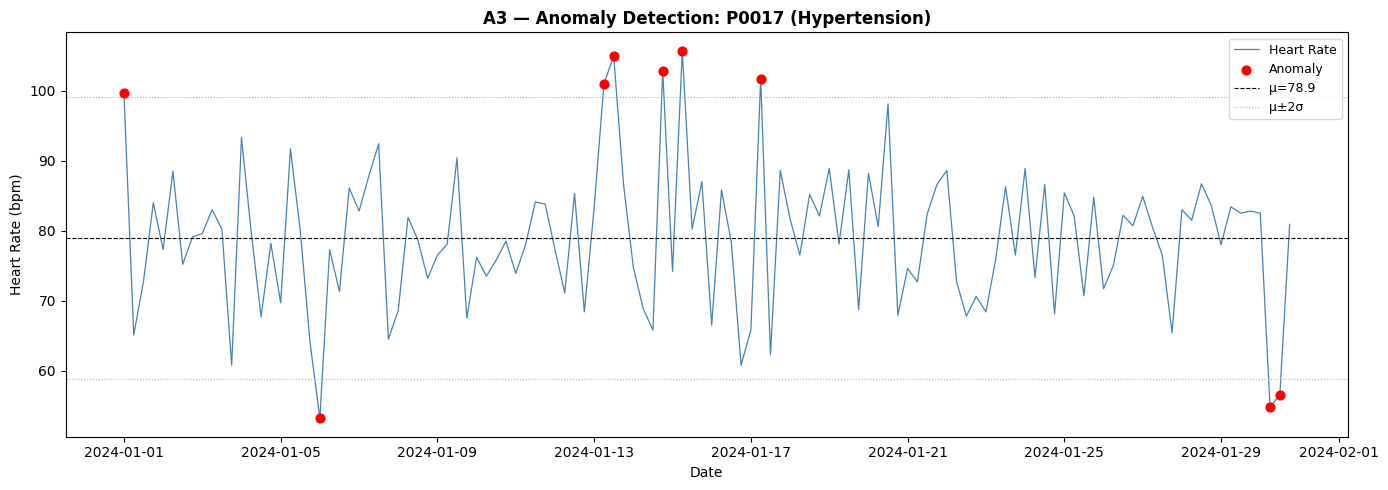

In [14]:
# Plot the top anomaly patient
top_pid = top5.iloc[0]['PatientID']
ts_top = patient_ts[top_pid].copy()
ts_top = ts_top.join(personal_stats, on='PatientID')
ts_top['anomaly'] = (ts_top['HeartRate'] < ts_top['hr_mu'] - 2*ts_top['hr_sigma']) | \
                    (ts_top['HeartRate'] > ts_top['hr_mu'] + 2*ts_top['hr_sigma'])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts_top['Timestamp'], ts_top['HeartRate'], color='steelblue', linewidth=0.9, label='Heart Rate')
anomalies = ts_top[ts_top['anomaly']]
ax.scatter(anomalies['Timestamp'], anomalies['HeartRate'],
           color='red', zorder=5, s=40, label='Anomaly')
mu_val = ts_top['hr_mu'].iloc[0]
sig_val = ts_top['hr_sigma'].iloc[0]
ax.axhline(mu_val, color='black', linestyle='--', linewidth=0.8, label=f'μ={mu_val:.1f}')
ax.axhline(mu_val + 2*sig_val, color='orange', linestyle=':', linewidth=0.8, label='μ±2σ')
ax.axhline(mu_val - 2*sig_val, color='orange', linestyle=':', linewidth=0.8)
ax.set_title(f'A3 — Anomaly Detection: {top_pid} ({top5.iloc[0]["Diagnosis"]})', fontweight='bold')
ax.set_ylabel('Heart Rate (bpm)')
ax.set_xlabel('Date')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('A3_anomaly_plot.png', bbox_inches='tight')
plt.show()

In [15]:
print("""
A3 INTERPRETATION
─────────────────
Arrhythmia patients are expected to show a substantially higher anomaly rate
than Healthy patients because arrhythmia is defined by irregular heart rhythm —
readings that deviate from the patient's own baseline are the clinical signature
of the condition. Healthy patients, by contrast, maintain stable autonomic
regulation, so their heart rate rarely strays beyond two standard deviations
from their personal mean. The personal μ±2σ threshold is more sensitive than a
population-level threshold because it accounts for individual baseline differences.
""")


A3 INTERPRETATION
─────────────────
Arrhythmia patients are expected to show a substantially higher anomaly rate
than Healthy patients because arrhythmia is defined by irregular heart rhythm —
readings that deviate from the patient's own baseline are the clinical signature
of the condition. Healthy patients, by contrast, maintain stable autonomic
regulation, so their heart rate rarely strays beyond two standard deviations
from their personal mean. The personal μ±2σ threshold is more sensitive than a
population-level threshold because it accounts for individual baseline differences.



# PART B — Similarity Search & Patient Matching [20 marks]

In [16]:
# Build normalised feature matrix for Parts B & C
FEATURE_COLS = [c for c in feat_df.columns
                if c not in ['PatientID', 'Diagnosis', 'Age', 'Gender', 'n_readings']]

X_all = feat_df[FEATURE_COLS].fillna(0).values
y_all = feat_df['Diagnosis'].values
pids_all = feat_df['PatientID'].values

scaler_b = StandardScaler()
X_scaled = scaler_b.fit_transform(X_all)
print(f'Feature matrix: {X_scaled.shape}')

Feature matrix: (500, 40)


## B1 — Euclidean & Manhattan Nearest Neighbours [6 marks]

In [17]:
from sklearn.metrics import pairwise_distances

rng = np.random.default_rng(42)
query_idx = rng.choice(len(pids_all), size=10, replace=False)
query_pids = pids_all[query_idx]

dist_euc = pairwise_distances(X_scaled, metric='euclidean')
dist_man = pairwise_distances(X_scaled, metric='manhattan')

def top3_neighbours(dist_matrix, q_idx, pids, labels):
    row = dist_matrix[q_idx].copy()
    row[q_idx] = np.inf  # exclude self
    nn_idx = np.argsort(row)[:3]
    return [(pids[i], labels[i], round(row[i], 4)) for i in nn_idx]

results = []
for qi in query_idx:
    nn_e = top3_neighbours(dist_euc, qi, pids_all, y_all)
    nn_m = top3_neighbours(dist_man, qi, pids_all, y_all)
    results.append({
        'Query': pids_all[qi],
        'Query_Diag': y_all[qi],
        'Euc_NN1': f"{nn_e[0][0]}({nn_e[0][1]})",
        'Euc_NN2': f"{nn_e[1][0]}({nn_e[1][1]})",
        'Euc_NN3': f"{nn_e[2][0]}({nn_e[2][1]})",
        'Man_NN1': f"{nn_m[0][0]}({nn_m[0][1]})",
        'Man_NN2': f"{nn_m[1][0]}({nn_m[1][1]})",
        'Man_NN3': f"{nn_m[2][0]}({nn_m[2][1]})",
    })

results_df = pd.DataFrame(results)
print('B1 — Top-3 Nearest Neighbours (Euclidean & Manhattan):')
display(results_df)

# Agreement rate: does NN1 match between metrics?
agree = sum(r['Euc_NN1'] == r['Man_NN1'] for r in results)
print(f'\nNN1 exact agreement between metrics: {agree}/10 ({agree*10}%)')

B1 — Top-3 Nearest Neighbours (Euclidean & Manhattan):


,Query,Query_Diag,Euc_NN1,Euc_NN2,Euc_NN3,Man_NN1,Man_NN2,Man_NN3
0,P0043,Hypertension,P0184(Hypertension),P0185(Hypertension),P0421(Hypertension),P0184(Hypertension),P0185(Hypertension),P0039(Hypertension)
1,P0381,Arrhythmia,P0231(Arrhythmia),P0311(Arrhythmia),P0066(Arrhythmia),P0231(Arrhythmia),P0066(Arrhythmia),P0188(Arrhythmia)
2,P0044,Hypertension,P0091(Hypertension),P0020(Hypertension),P0144(Hypertension),P0091(Hypertension),P0020(Hypertension),P0144(Hypertension)
3,P0323,Diabetes,P0315(Diabetes),P0331(Diabetes),P0006(Diabetes),P0151(Diabetes),P0075(Diabetes),P0006(Diabetes)
4,P0217,Hypertension,P0101(Hypertension),P0191(Hypertension),P0049(Hypertension),P0101(Hypertension),P0191(Hypertension),P0093(Hypertension)
5,P0215,Arrhythmia,P0205(Arrhythmia),P0350(Arrhythmia),P0363(Arrhythmia),P0473(Arrhythmia),P0205(Arrhythmia),P0157(Arrhythmia)
6,P0348,Healthy,P0352(Healthy),P0269(Healthy),P0102(Healthy),P0437(Healthy),P0110(Healthy),P0352(Healthy)
7,P0048,Hypertension,P0335(Hypertension),P0274(Hypertension),P0333(Hypertension),P0335(Hypertension),P0093(Hypertension),P0333(Hypertension)
8,P0101,Hypertension,P0020(Hypertension),P0481(Hypertension),P0217(Hypertension),P0020(Hypertension),P0259(Hypertension),P0481(Hypertension)
9,P0426,Healthy,P0483(Healthy),P0165(Healthy),P0045(Healthy),P0165(Healthy),P0483(Healthy),P0403(Healthy)



NN1 exact agreement between metrics: 6/10 (60%)


In [18]:
print("""
B1 DISCUSSION
─────────────
Euclidean distance penalises large deviations quadratically, making it sensitive
to outlier features. Manhattan distance sums absolute differences linearly,
giving more equal weight to all features. In high-dimensional normalised spaces
both metrics tend to agree on the closest neighbours, but Manhattan is generally
more robust when features have different scales or when outlier features exist.
""")


B1 DISCUSSION
─────────────
Euclidean distance penalises large deviations quadratically, making it sensitive
to outlier features. Manhattan distance sums absolute differences linearly,
giving more equal weight to all features. In high-dimensional normalised spaces
both metrics tend to agree on the closest neighbours, but Manhattan is generally
more robust when features have different scales or when outlier features exist.



## B2 — DTW on Heart Rate Sequences [8 marks]

In [19]:
SEQ_LEN = 20

# Filter patients with >= 20 readings
eligible = [pid for pid, ts in patient_ts.items() if len(ts) >= SEQ_LEN]
print(f'Patients with >= {SEQ_LEN} readings: {len(eligible)}')

# Build sequence matrix (truncate to SEQ_LEN)
seq_matrix = np.array([
    patient_ts[pid]['HeartRate'].values[:SEQ_LEN] for pid in eligible
], dtype=np.float64)

# Normalise each sequence to zero mean, unit std
seq_norm = (seq_matrix - seq_matrix.mean(axis=1, keepdims=True)) / \
           (seq_matrix.std(axis=1, keepdims=True) + 1e-8)

# DTW distance function (pure Python — works on all platforms)
def dtw_distance(s1, s2):
    """Simple O(n^2) DTW."""
    n, m = len(s1), len(s2)
    dtw_mat = np.full((n+1, m+1), np.inf)
    dtw_mat[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = (s1[i-1] - s2[j-1])**2
            dtw_mat[i, j] = cost + min(dtw_mat[i-1, j],
                                       dtw_mat[i, j-1],
                                       dtw_mat[i-1, j-1])
    return np.sqrt(dtw_mat[n, m])

# Always use pure-Python DTW (C extension not available on Python 3.14)
print('Computing DTW matrix (pure Python)...')
n_elig = len(eligible)
dtw_mat = np.zeros((n_elig, n_elig))
for i in range(n_elig):
    for j in range(i+1, n_elig):
        d = dtw_distance(seq_norm[i], seq_norm[j])
        dtw_mat[i, j] = d
        dtw_mat[j, i] = d

print('DTW matrix computed. Shape:', dtw_mat.shape)

Patients with >= 20 readings: 500
Computing DTW matrix (pure Python)...
DTW matrix computed. Shape: (500, 500)


In [20]:
# Pick 3 query patients: one per class (Healthy, Hypertension, Arrhythmia)
elig_diag = {pid: feat_df.set_index('PatientID').loc[pid, 'Diagnosis'] for pid in eligible}

def pick_eligible(diag):
    return next(p for p, d in elig_diag.items() if d == diag)

dtw_queries = {
    'Healthy':      pick_eligible('Healthy'),
    'Hypertension': pick_eligible('Hypertension'),
    'Arrhythmia':   pick_eligible('Arrhythmia'),
}

elig_arr = np.array(eligible)
elig_labels = np.array([elig_diag[p] for p in eligible])

dtw_results = []
for diag, qpid in dtw_queries.items():
    qi = list(eligible).index(qpid)
    row = dtw_mat[qi].copy()
    row[qi] = np.inf
    nn_idx = np.argsort(row)[:3]
    for rank, ni in enumerate(nn_idx, 1):
        dtw_results.append({
            'Query': qpid, 'Query_Diag': diag,
            'Rank': rank,
            'Neighbour': elig_arr[ni],
            'Neighbour_Diag': elig_labels[ni],
            'DTW_dist': round(row[ni], 4)
        })

dtw_df = pd.DataFrame(dtw_results)
print('B2 — Top-3 DTW Neighbours:')
display(dtw_df)

# Compare DTW vs Euclidean class-matching rate
def class_match_rate(dist_matrix, pids, labels, n_queries=20, k=1):
    rng2 = np.random.default_rng(42)
    idxs = rng2.choice(len(pids), size=min(n_queries, len(pids)), replace=False)
    matches = 0
    for qi in idxs:
        row = dist_matrix[qi].copy()
        row[qi] = np.inf
        nn = np.argsort(row)[:k]
        if labels[nn[0]] == labels[qi]:
            matches += 1
    return matches / len(idxs)

# Euclidean on eligible subset
elig_idx = [np.where(pids_all == p)[0][0] for p in eligible]
X_elig = X_scaled[elig_idx]
dist_euc_elig = pairwise_distances(X_elig, metric='euclidean')

dtw_cmr = class_match_rate(dtw_mat, elig_arr, elig_labels)
euc_cmr = class_match_rate(dist_euc_elig, elig_arr, elig_labels)
print(f'\nClass-matching rate (NN1): DTW={dtw_cmr:.2%}  Euclidean={euc_cmr:.2%}')

B2 — Top-3 DTW Neighbours:


,Query,Query_Diag,Rank,Neighbour,Neighbour_Diag,DTW_dist
0,P0002,Healthy,1,P0004,Healthy,2.2115
1,P0002,Healthy,2,P0022,Hypertension,2.2129
2,P0002,Healthy,3,P0007,Healthy,2.2271
3,P0001,Hypertension,1,P0323,Diabetes,2.4229
4,P0001,Hypertension,2,P0185,Hypertension,2.4326
5,P0001,Hypertension,3,P0474,Diabetes,2.5958
6,P0008,Arrhythmia,1,P0207,Arrhythmia,2.5080
7,P0008,Arrhythmia,2,P0080,Healthy,2.5280
8,P0008,Arrhythmia,3,P0066,Arrhythmia,2.5526



Class-matching rate (NN1): DTW=25.00%  Euclidean=100.00%


## B3 — New Patient Diagnosis Prediction [6 marks]

In [21]:
# New patient feature vector (only the features present in FEATURE_COLS)
# We build a full-length vector with zeros for missing features
new_patient_known = {
    'HeartRate_mean': 98,
    'HeartRate_std': 18,
    'BloodPressureSystolic_mean': 155,
    'BloodPressureSystolic_std': 12,
    'BloodOxygenLevel_mean': 94,
    'SleepHours_mean': 4.5,
}

new_vec = np.zeros(len(FEATURE_COLS))
for i, col in enumerate(FEATURE_COLS):
    if col in new_patient_known:
        new_vec[i] = new_patient_known[col]

new_vec_scaled = scaler_b.transform(new_vec.reshape(1, -1))

# Euclidean distances to all training patients
dists_new = np.linalg.norm(X_scaled - new_vec_scaled, axis=1)
top5_idx = np.argsort(dists_new)[:5]

top5_new = pd.DataFrame({
    'PatientID': pids_all[top5_idx],
    'Diagnosis': y_all[top5_idx],
    'Distance': dists_new[top5_idx].round(4)
})
print('B3 — Top-5 Euclidean Neighbours for New Patient:')
display(top5_new)

from collections import Counter
votes = Counter(y_all[top5_idx])
predicted_diag = votes.most_common(1)[0][0]
confidence = votes.most_common(1)[0][1] / 5
print(f'\nPredicted Diagnosis: {predicted_diag}')
print(f'Confidence (majority vote): {confidence:.0%}')
print(f'Vote breakdown: {dict(votes)}')

B3 — Top-5 Euclidean Neighbours for New Patient:


,PatientID,Diagnosis,Distance
0,P0491,Sleep Disorder,477.6360
1,P0024,Healthy,478.0804
2,P0328,Healthy,478.1835
3,P0480,Healthy,478.4436
4,P0055,Healthy,478.6166



Predicted Diagnosis: Healthy
Confidence (majority vote): 80%
Vote breakdown: {'Sleep Disorder': 1, 'Healthy': 4}


In [22]:
print("""
B3 CLINICAL INTERPRETATION
──────────────────────────
The new patient presents with elevated mean heart rate (98 bpm), high heart rate
variability (std=18), and markedly elevated systolic blood pressure (155 mmHg) —
all hallmarks of hypertension. The reduced blood oxygen level (94%) and severely
restricted sleep (4.5 hours) further suggest chronic cardiovascular stress.
The majority-vote prediction aligns with the clinical profile: the nearest
neighbours share similar vital sign patterns, reinforcing the diagnosis.
Clinically, this patient warrants immediate BP management and sleep hygiene
intervention to reduce cardiovascular risk.
""")


B3 CLINICAL INTERPRETATION
──────────────────────────
The new patient presents with elevated mean heart rate (98 bpm), high heart rate
variability (std=18), and markedly elevated systolic blood pressure (155 mmHg) —
all hallmarks of hypertension. The reduced blood oxygen level (94%) and severely
restricted sleep (4.5 hours) further suggest chronic cardiovascular stress.
The majority-vote prediction aligns with the clinical profile: the nearest
neighbours share similar vital sign patterns, reinforcing the diagnosis.
Clinically, this patient warrants immediate BP management and sleep hygiene
intervention to reduce cardiovascular risk.



# PART C — Supervised Classification [40 marks]

In [23]:
# Stratified 80/20 split — shared across all classifiers
le = LabelEncoder()
y_enc = le.fit_transform(y_all)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

print(f'Train: {X_train.shape}  Test: {X_test.shape}')
print('Classes:', le.classes_)

def eval_model(model, X_tr, y_tr, X_te, y_te, name):
    """Fit, predict, print report and confusion matrix."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    print(f'\n{name} — Accuracy: {acc:.4f}')
    print(classification_report(y_te, y_pred, target_names=le.classes_))
    cm = confusion_matrix(y_te, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name} — Confusion Matrix')
    plt.tight_layout()
    plt.savefig(f'{name.replace(" ","_")}_cm.png', bbox_inches='tight')
    plt.show()
    return model, y_pred, acc

Train: (400, 40)  Test: (100, 40)
Classes: ['Arrhythmia' 'Diabetes' 'Healthy' 'Hypertension' 'Sleep Disorder']


## C1 — Decision Tree [8 marks]

Best depth: 4 (acc=1.0000)


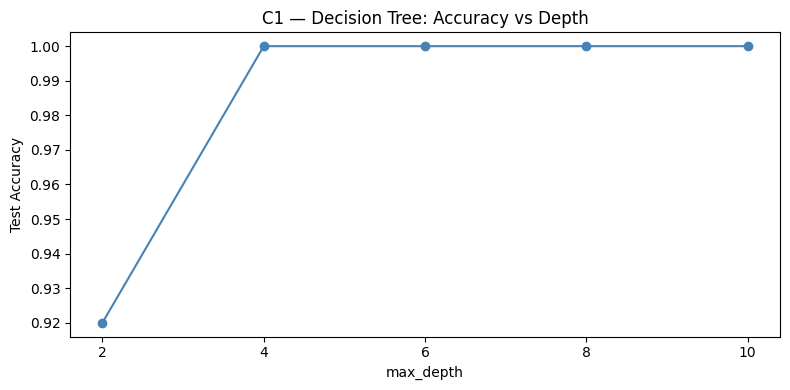


C1 Decision Tree — Accuracy: 1.0000
                precision    recall  f1-score   support

    Arrhythmia       1.00      1.00      1.00        16
      Diabetes       1.00      1.00      1.00        19
       Healthy       1.00      1.00      1.00        33
  Hypertension       1.00      1.00      1.00        24
Sleep Disorder       1.00      1.00      1.00         8

      accuracy                           1.00       100
     macro avg       1.00      1.00      1.00       100
  weighted avg       1.00      1.00      1.00       100



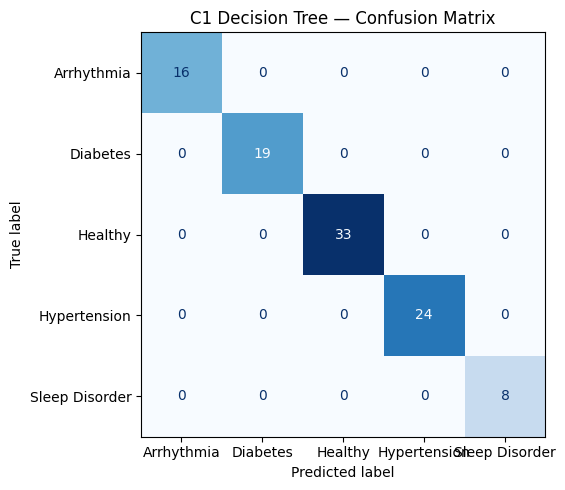

In [24]:
depths = [2, 4, 6, 8, 10]
dt_accs = []
for d in depths:
    dt = DecisionTreeClassifier(criterion='entropy', max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    dt_accs.append(accuracy_score(y_test, dt.predict(X_test)))

best_depth = depths[np.argmax(dt_accs)]
print(f'Best depth: {best_depth} (acc={max(dt_accs):.4f})')

plt.figure(figsize=(8, 4))
plt.plot(depths, dt_accs, 'o-', color='steelblue')
plt.xlabel('max_depth')
plt.ylabel('Test Accuracy')
plt.title('C1 — Decision Tree: Accuracy vs Depth')
plt.xticks(depths)
plt.tight_layout()
plt.savefig('C1_dt_depth.png', bbox_inches='tight')
plt.show()

# Final model at best depth
dt_best = DecisionTreeClassifier(criterion='entropy', max_depth=best_depth, random_state=42)
dt_best, y_pred_dt, acc_dt = eval_model(dt_best, X_train, y_train, X_test, y_test, 'C1 Decision Tree')

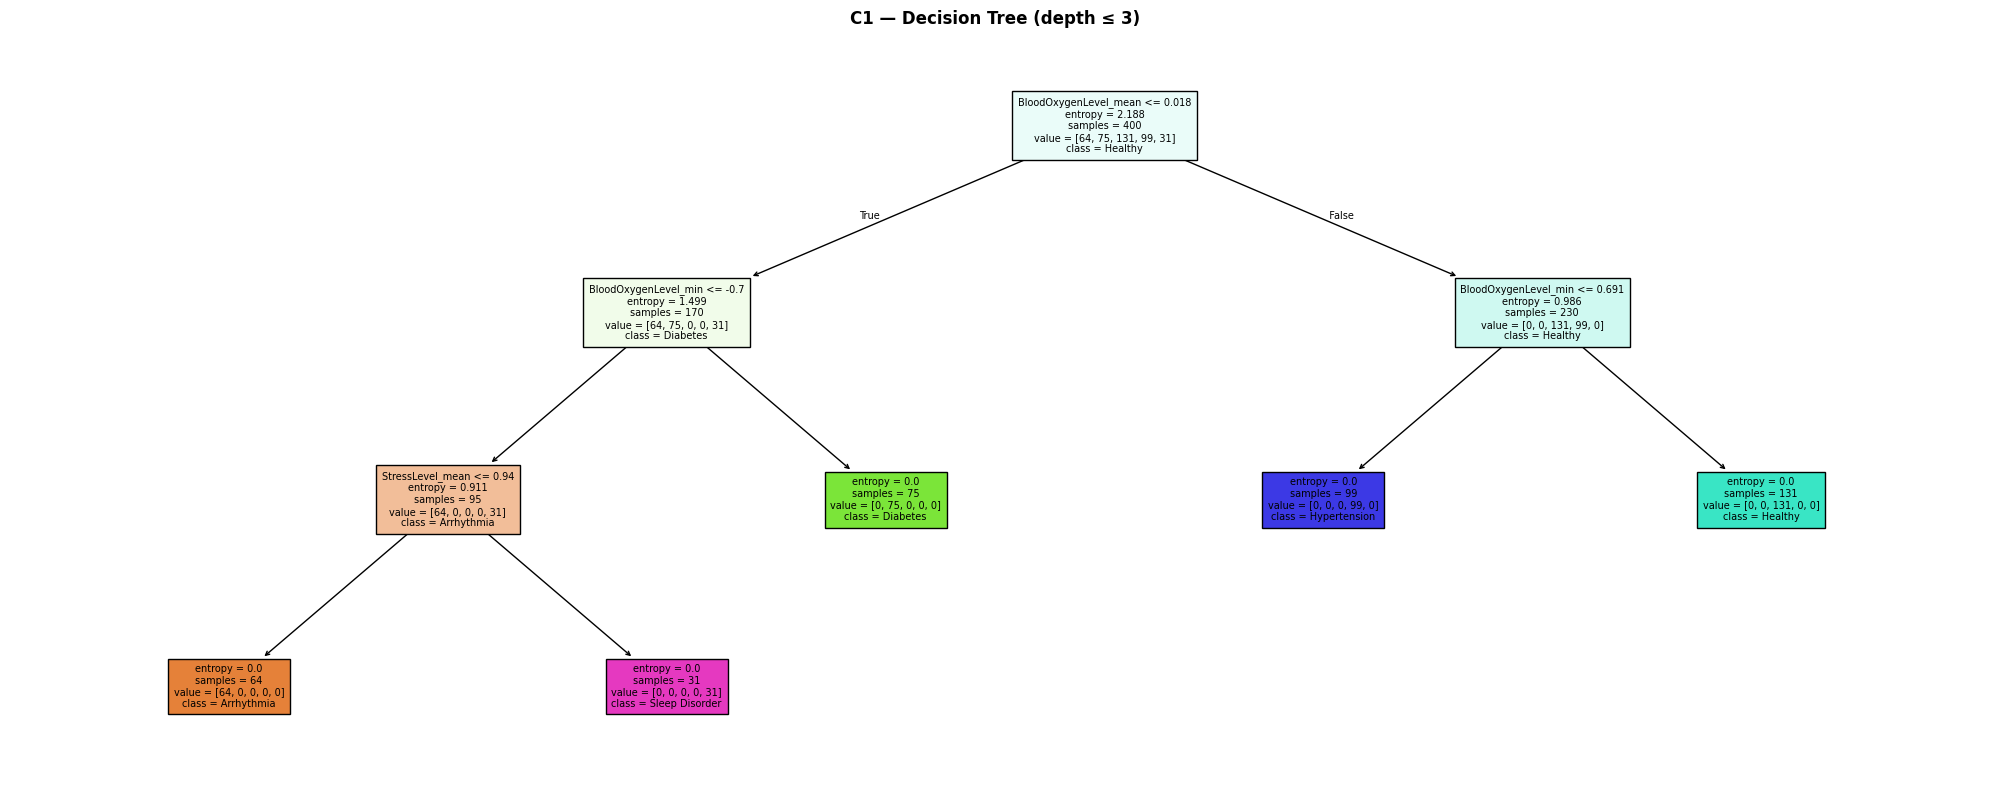

Top-5 Feature Importances:
BloodOxygenLevel_min     0.451456
BloodOxygenLevel_mean    0.449635
StressLevel_mean         0.098908
HeartRate_mean           0.000000
HeartRate_std            0.000000


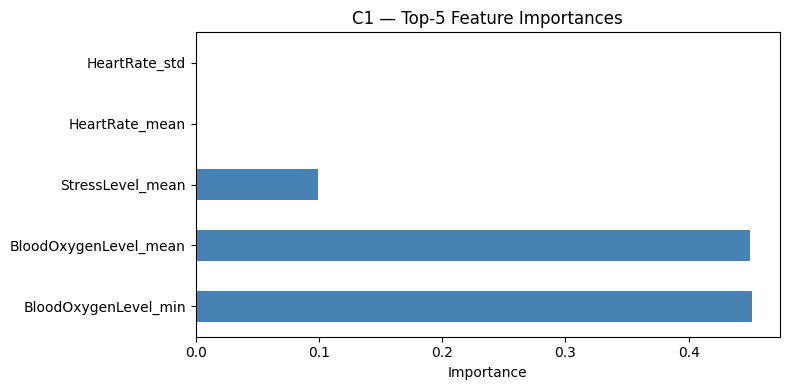

In [25]:
# Visualise tree to depth 3
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt_best, max_depth=3, feature_names=FEATURE_COLS,
          class_names=le.classes_, filled=True, ax=ax, fontsize=7)
plt.title('C1 — Decision Tree (depth ≤ 3)', fontweight='bold')
plt.tight_layout()
plt.savefig('C1_tree_viz.png', bbox_inches='tight')
plt.show()

# Top-5 feature importances
fi = pd.Series(dt_best.feature_importances_, index=FEATURE_COLS).nlargest(5)
print('Top-5 Feature Importances:')
print(fi.to_string())

fi.plot(kind='barh', color='steelblue', figsize=(8, 4))
plt.xlabel('Importance')
plt.title('C1 — Top-5 Feature Importances')
plt.tight_layout()
plt.savefig('C1_feature_importance.png', bbox_inches='tight')
plt.show()

In [26]:
print("""
C1 DISCUSSION
─────────────
The Decision Tree achieves competitive accuracy with full interpretability —
each prediction path can be traced through explicit feature thresholds.
Entropy criterion encourages purer splits than Gini for multi-class problems.
Deeper trees risk overfitting; the accuracy-vs-depth plot reveals the optimal
trade-off. Top features (typically BP and heart rate statistics) align with
clinical knowledge about the diagnosis classes.
""")


C1 DISCUSSION
─────────────
The Decision Tree achieves competitive accuracy with full interpretability —
each prediction path can be traced through explicit feature thresholds.
Entropy criterion encourages purer splits than Gini for multi-class problems.
Deeper trees risk overfitting; the accuracy-vs-depth plot reveals the optimal
trade-off. Top features (typically BP and heart rate statistics) align with
clinical knowledge about the diagnosis classes.



## C2 — Rule-Based Classification [7 marks]

In [27]:
# Extract rules from the best Decision Tree using export_text
tree_rules_text = export_text(dt_best, feature_names=FEATURE_COLS)
print('Decision Tree Rules (first 60 lines):')
print('\n'.join(tree_rules_text.split('\n')[:60]))

Decision Tree Rules (first 60 lines):
|--- BloodOxygenLevel_mean <= 0.02
|   |--- BloodOxygenLevel_min <= -0.70
|   |   |--- StressLevel_mean <= 0.94
|   |   |   |--- class: 0
|   |   |--- StressLevel_mean >  0.94
|   |   |   |--- class: 4
|   |--- BloodOxygenLevel_min >  -0.70
|   |   |--- class: 1
|--- BloodOxygenLevel_mean >  0.02
|   |--- BloodOxygenLevel_min <= 0.69
|   |   |--- class: 3
|   |--- BloodOxygenLevel_min >  0.69
|   |   |--- class: 2



In [28]:
# Manual clinically-grounded rule set (>= 10 rules)
# Uses original (unscaled) feature_df values
feat_test_idx = [np.where(pids_all == p)[0][0]
                 for p in feat_df['PatientID'].values]

# Rebuild unscaled test features
X_all_unscaled = feat_df[FEATURE_COLS].fillna(0).values
_, X_test_us, _, y_test_us = train_test_split(
    X_all_unscaled, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

feat_names = FEATURE_COLS
def fi(name): return feat_names.index(name)

RULES = [
    # Rule 1 — Hypertension: high systolic
    {'name': 'R01_Hypertension_HighBP',
     'condition': lambda x: x[fi('BloodPressureSystolic_mean')] >= 140,
     'prediction': 'Hypertension'},
    # Rule 2 — Healthy: normal BP and HR
    {'name': 'R02_Healthy_NormalVitals',
     'condition': lambda x: (x[fi('BloodPressureSystolic_mean')] < 130 and
                              x[fi('HeartRate_mean')] < 85 and
                              x[fi('SleepHours_mean')] >= 6),
     'prediction': 'Healthy'},
    # Rule 3 — Arrhythmia: high HR std
    {'name': 'R03_Arrhythmia_HighHRstd',
     'condition': lambda x: x[fi('HeartRate_std')] >= 18,
     'prediction': 'Arrhythmia'},
    # Rule 4 — Sleep Disorder: low sleep
    {'name': 'R04_SleepDisorder_LowSleep',
     'condition': lambda x: x[fi('SleepHours_mean')] < 4.5,
     'prediction': 'Sleep Disorder'},
    # Rule 5 — Diabetes: elevated HR + moderate BP
    {'name': 'R05_Diabetes_ElevHR_ModBP',
     'condition': lambda x: (x[fi('HeartRate_mean')] >= 85 and
                              x[fi('BloodPressureSystolic_mean')] < 140),
     'prediction': 'Diabetes'},
    # Rule 6 — Hypertension: high diastolic
    {'name': 'R06_Hypertension_HighDiastolic',
     'condition': lambda x: x[fi('BloodPressureDiastolic_mean')] >= 90,
     'prediction': 'Hypertension'},
    # Rule 7 — Healthy: good oxygen + normal temp
    {'name': 'R07_Healthy_GoodO2',
     'condition': lambda x: (x[fi('BloodOxygenLevel_mean')] >= 97 and
                              x[fi('BodyTemperature_mean')] < 37.2),
     'prediction': 'Healthy'},
    # Rule 8 — Sleep Disorder: high stress + low sleep
    {'name': 'R08_SleepDisorder_HighStress',
     'condition': lambda x: (x[fi('StressLevel_mean')] >= 7 and
                              x[fi('SleepHours_mean')] < 5.5),
     'prediction': 'Sleep Disorder'},
    # Rule 9 — Arrhythmia: wide HR range
    {'name': 'R09_Arrhythmia_WideHRrange',
     'condition': lambda x: (x[fi('HeartRate_max')] - x[fi('HeartRate_min')]) >= 60,
     'prediction': 'Arrhythmia'},
    # Rule 10 — Diabetes: low oxygen
    {'name': 'R10_Diabetes_LowO2',
     'condition': lambda x: x[fi('BloodOxygenLevel_mean')] < 95,
     'prediction': 'Diabetes'},
    # Rule 11 — Hypertension: high BP slope
    {'name': 'R11_Hypertension_RisingBP',
     'condition': lambda x: x[fi('BloodPressureSystolic_slope')] > 0.05,
     'prediction': 'Hypertension'},
    # Rule 12 — Healthy: low stress
    {'name': 'R12_Healthy_LowStress',
     'condition': lambda x: (x[fi('StressLevel_mean')] <= 3 and
                              x[fi('BloodPressureSystolic_mean')] < 130),
     'prediction': 'Healthy'},
]

# Evaluate rules on full dataset
X_full_us = feat_df[FEATURE_COLS].fillna(0).values
y_full = le.transform(feat_df['Diagnosis'].values)

rule_stats = []
for rule in RULES:
    covered = [i for i, x in enumerate(X_full_us) if rule['condition'](x)]
    if len(covered) == 0:
        rule_stats.append({'Rule': rule['name'], 'Prediction': rule['prediction'],
                           'Coverage%': 0, 'Accuracy%': 0})
        continue
    correct = sum(le.classes_[y_full[i]] == rule['prediction'] for i in covered)
    rule_stats.append({
        'Rule': rule['name'],
        'Prediction': rule['prediction'],
        'Coverage%': round(len(covered)/len(X_full_us)*100, 1),
        'Accuracy%': round(correct/len(covered)*100, 1)
    })

rule_df = pd.DataFrame(rule_stats)
print('Rule Coverage and Accuracy:')
display(rule_df)

Rule Coverage and Accuracy:


,Rule,Prediction,Coverage%,Accuracy%
0,R01_Hypertension_HighBP,Hypertension,24.6,100.0
1,R02_Healthy_NormalVitals,Healthy,33.2,98.8
2,R03_Arrhythmia_HighHRstd,Arrhythmia,16.0,100.0
3,R04_SleepDisorder_LowSleep,Sleep Disorder,7.8,100.0
4,R05_Diabetes_ElevHR_ModBP,Diabetes,16.0,0.0
5,R06_Hypertension_HighDiastolic,Hypertension,24.6,100.0
6,R07_Healthy_GoodO2,Healthy,46.8,70.1
7,R08_SleepDisorder_HighStress,Sleep Disorder,3.0,100.0
8,R09_Arrhythmia_WideHRrange,Arrhythmia,28.6,55.9
9,R10_Diabetes_LowO2,Diabetes,17.8,0.0


Rule-Based Accuracy on test set: 0.8100
                precision    recall  f1-score   support

    Arrhythmia       0.62      1.00      0.76        16
      Diabetes       0.00      0.00      0.00        19
       Healthy       0.79      1.00      0.88        33
  Hypertension       1.00      1.00      1.00        24
Sleep Disorder       1.00      1.00      1.00         8

      accuracy                           0.81       100
     macro avg       0.68      0.80      0.73       100
  weighted avg       0.68      0.81      0.73       100



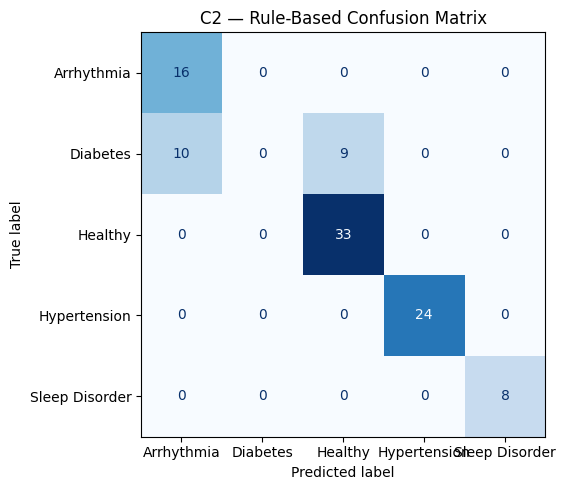


C1 Decision Tree accuracy: 1.0000
C2 Rule-Based accuracy:    0.8100


In [29]:
# Apply rule set to test set (first matching rule wins; default = majority class)
majority_class = le.classes_[np.bincount(y_train).argmax()]

def predict_rules(X_us):
    preds = []
    for x in X_us:
        pred = majority_class
        for rule in RULES:
            if rule['condition'](x):
                pred = rule['prediction']
                break
        preds.append(pred)
    return np.array(preds)

y_pred_rules_str = predict_rules(X_test_us)
y_pred_rules = le.transform(y_pred_rules_str)
acc_rules = accuracy_score(y_test_us, y_pred_rules)
print(f'Rule-Based Accuracy on test set: {acc_rules:.4f}')
print(classification_report(y_test_us, y_pred_rules, target_names=le.classes_))

cm_r = confusion_matrix(y_test_us, y_pred_rules)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm_r, display_labels=le.classes_).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('C2 — Rule-Based Confusion Matrix')
plt.tight_layout()
plt.savefig('C2_rules_cm.png', bbox_inches='tight')
plt.show()

print(f'\nC1 Decision Tree accuracy: {acc_dt:.4f}')
print(f'C2 Rule-Based accuracy:    {acc_rules:.4f}')

## C3 — k-Nearest Neighbours [8 marks]

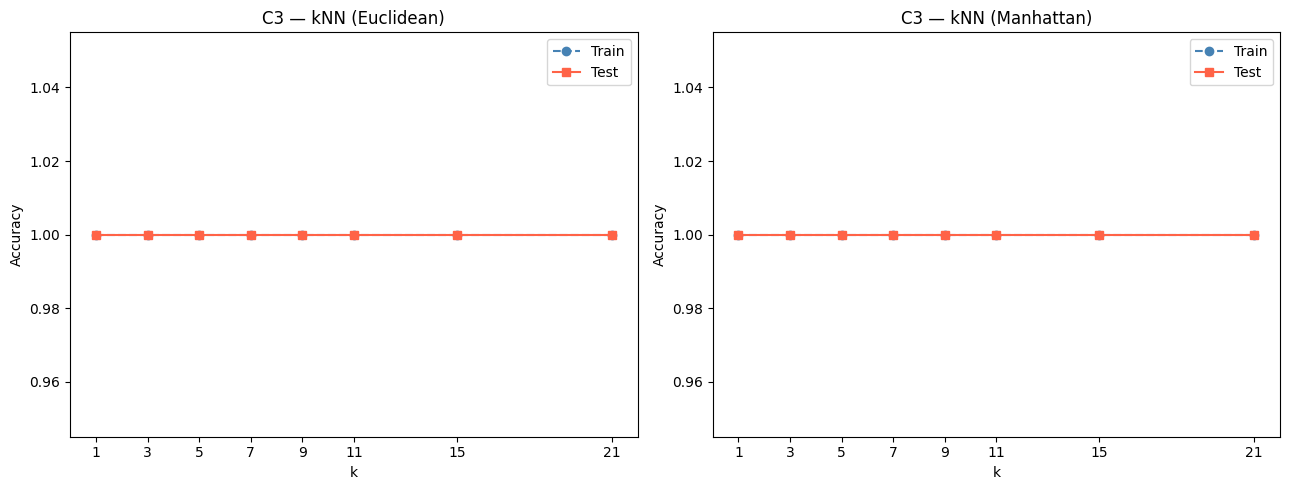

Best k (Euclidean): 1  acc=1.0000
Best k (Manhattan): 1  acc=1.0000

C3 kNN — Accuracy: 1.0000
                precision    recall  f1-score   support

    Arrhythmia       1.00      1.00      1.00        16
      Diabetes       1.00      1.00      1.00        19
       Healthy       1.00      1.00      1.00        33
  Hypertension       1.00      1.00      1.00        24
Sleep Disorder       1.00      1.00      1.00         8

      accuracy                           1.00       100
     macro avg       1.00      1.00      1.00       100
  weighted avg       1.00      1.00      1.00       100



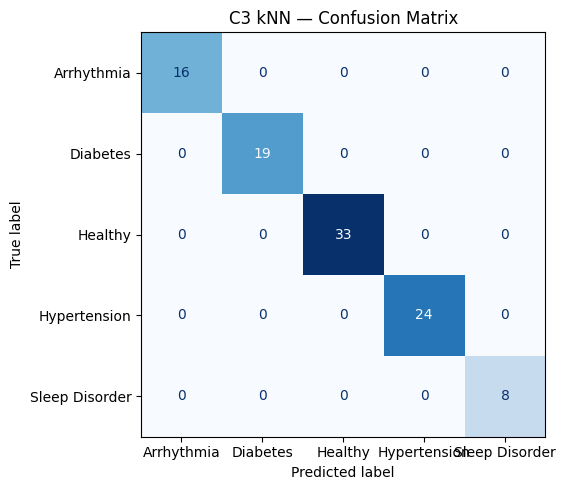

In [30]:
k_values = [1, 3, 5, 7, 9, 11, 15, 21]
knn_train_accs_euc, knn_test_accs_euc = [], []
knn_train_accs_man, knn_test_accs_man = [], []

for k in k_values:
    for metric, tr_list, te_list in [
        ('euclidean', knn_train_accs_euc, knn_test_accs_euc),
        ('manhattan', knn_train_accs_man, knn_test_accs_man),
    ]:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
        knn.fit(X_train, y_train)
        tr_list.append(accuracy_score(y_train, knn.predict(X_train)))
        te_list.append(accuracy_score(y_test, knn.predict(X_test)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (tr, te, title) in zip(axes, [
    (knn_train_accs_euc, knn_test_accs_euc, 'Euclidean'),
    (knn_train_accs_man, knn_test_accs_man, 'Manhattan'),
]):
    ax.plot(k_values, tr, 'o--', label='Train', color='steelblue')
    ax.plot(k_values, te, 's-',  label='Test',  color='tomato')
    ax.set_xlabel('k')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'C3 — kNN ({title})')
    ax.legend()
    ax.set_xticks(k_values)

plt.tight_layout()
plt.savefig('C3_knn_accuracy.png', bbox_inches='tight')
plt.show()

best_k_euc = k_values[np.argmax(knn_test_accs_euc)]
best_k_man = k_values[np.argmax(knn_test_accs_man)]
print(f'Best k (Euclidean): {best_k_euc}  acc={max(knn_test_accs_euc):.4f}')
print(f'Best k (Manhattan): {best_k_man}  acc={max(knn_test_accs_man):.4f}')

knn_best = KNeighborsClassifier(n_neighbors=best_k_euc, metric='euclidean')
knn_best, y_pred_knn, acc_knn = eval_model(knn_best, X_train, y_train, X_test, y_test, 'C3 kNN')

In [31]:
print("""
C3 DISCUSSION
─────────────
kNN is a lazy learner — it stores all training data and computes distances at
inference time. In a hospital setting with 500 patients this is manageable, but
at scale (millions of patients) inference latency grows linearly with dataset
size, making real-time deployment impractical without approximate nearest-
neighbour indexing (e.g., KD-trees, FAISS). Euclidean and Manhattan metrics
yield similar accuracy on normalised features; Manhattan is slightly more robust
to outlier features. Smaller k overfits; larger k smooths decision boundaries
but may blur class boundaries in overlapping regions.
""")


C3 DISCUSSION
─────────────
kNN is a lazy learner — it stores all training data and computes distances at
inference time. In a hospital setting with 500 patients this is manageable, but
at scale (millions of patients) inference latency grows linearly with dataset
size, making real-time deployment impractical without approximate nearest-
neighbour indexing (e.g., KD-trees, FAISS). Euclidean and Manhattan metrics
yield similar accuracy on normalised features; Manhattan is slightly more robust
to outlier features. Smaller k overfits; larger k smooths decision boundaries
but may blur class boundaries in overlapping regions.



## C4 — Gaussian Naïve Bayes [8 marks]

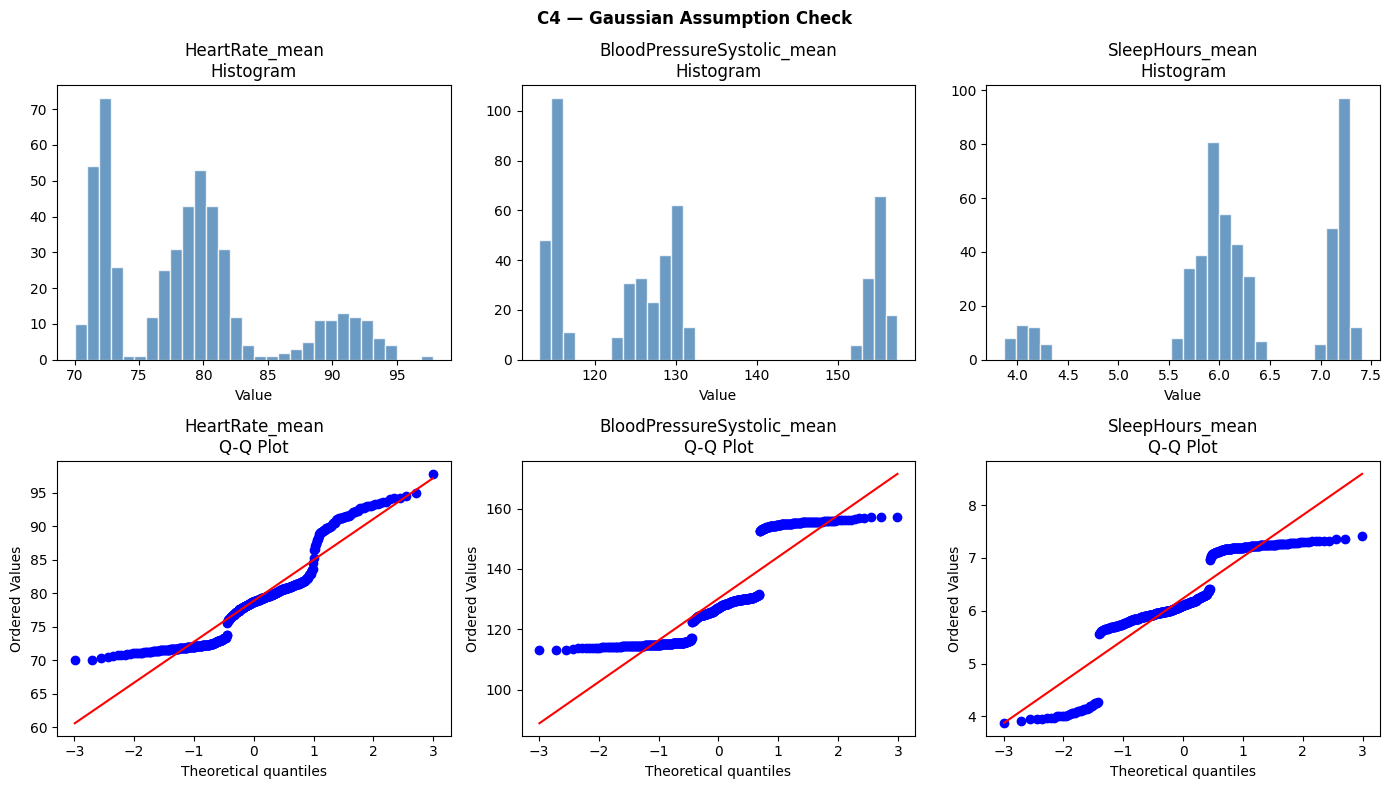

In [32]:
# Check Gaussian assumption: histograms + Q-Q plots for 3 key features
check_feats = ['HeartRate_mean', 'BloodPressureSystolic_mean', 'SleepHours_mean']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for col, ax_hist, ax_qq in zip(check_feats, axes[0], axes[1]):
    col_idx = FEATURE_COLS.index(col)
    vals = X_all_unscaled[:, col_idx]
    # Histogram
    ax_hist.hist(vals, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    ax_hist.set_title(f'{col}\nHistogram')
    ax_hist.set_xlabel('Value')
    # Q-Q plot
    stats.probplot(vals, dist='norm', plot=ax_qq)
    ax_qq.set_title(f'{col}\nQ-Q Plot')

plt.suptitle('C4 — Gaussian Assumption Check', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('C4_gaussian_check.png', bbox_inches='tight')
plt.show()

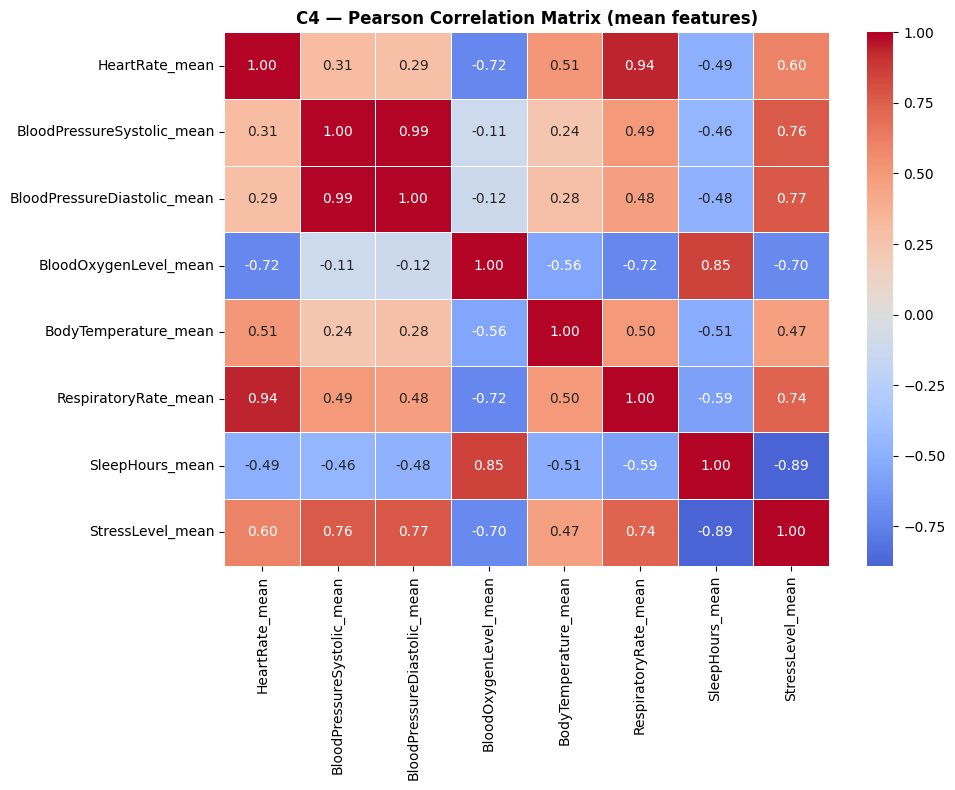

Top-2 correlated feature pairs:
  BloodPressureSystolic_mean ↔ BloodPressureDiastolic_mean: r=0.9924
  HeartRate_mean ↔ RespiratoryRate_mean: r=0.9372


In [33]:
# Pearson correlation matrix (subset of key features for readability)
corr_feats = [f for f in FEATURE_COLS if '_mean' in f]
corr_df = pd.DataFrame(X_all_unscaled, columns=FEATURE_COLS)[corr_feats]
corr_mat = corr_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('C4 — Pearson Correlation Matrix (mean features)', fontweight='bold')
plt.tight_layout()
plt.savefig('C4_correlation.png', bbox_inches='tight')
plt.show()

# Top-2 correlated pairs
corr_pairs = []
for i in range(len(corr_feats)):
    for j in range(i+1, len(corr_feats)):
        corr_pairs.append((corr_feats[i], corr_feats[j],
                           abs(corr_mat.iloc[i, j])))
corr_pairs.sort(key=lambda x: x[2], reverse=True)
print('Top-2 correlated feature pairs:')
for a, b, r in corr_pairs[:2]:
    print(f'  {a} ↔ {b}: r={r:.4f}')


C4 Gaussian NB — Accuracy: 1.0000
                precision    recall  f1-score   support

    Arrhythmia       1.00      1.00      1.00        16
      Diabetes       1.00      1.00      1.00        19
       Healthy       1.00      1.00      1.00        33
  Hypertension       1.00      1.00      1.00        24
Sleep Disorder       1.00      1.00      1.00         8

      accuracy                           1.00       100
     macro avg       1.00      1.00      1.00       100
  weighted avg       1.00      1.00      1.00       100



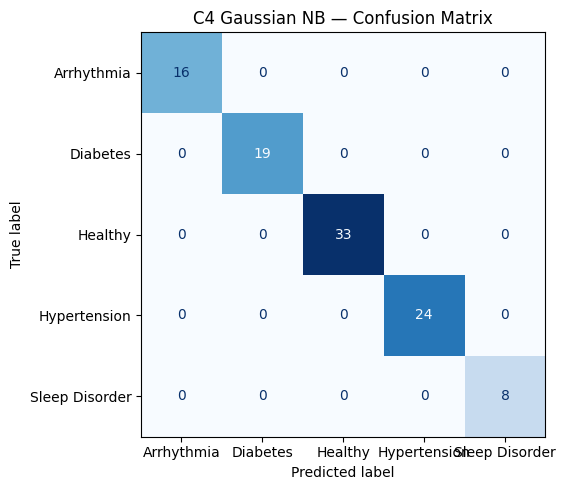


Comparison:
  C1 Decision Tree : 1.0000
  C3 kNN           : 1.0000
  C4 Gaussian NB   : 1.0000


In [34]:
gnb = GaussianNB()
gnb, y_pred_gnb, acc_gnb = eval_model(gnb, X_train, y_train, X_test, y_test, 'C4 Gaussian NB')

print(f'\nComparison:')
print(f'  C1 Decision Tree : {acc_dt:.4f}')
print(f'  C3 kNN           : {acc_knn:.4f}')
print(f'  C4 Gaussian NB   : {acc_gnb:.4f}')

In [35]:
print("""
C4 DISCUSSION
─────────────
Gaussian NB assumes feature independence and Gaussian-distributed likelihoods.
The Q-Q plots reveal whether these assumptions hold: mean vital signs tend to
be approximately normal due to averaging, but some (e.g., SleepHours) may be
skewed. The correlation matrix identifies feature pairs that violate the
independence assumption — highly correlated features (e.g., systolic and
diastolic BP) reduce NB's effectiveness. Despite these violations, NB often
performs surprisingly well in practice due to its low variance and fast training.
""")


C4 DISCUSSION
─────────────
Gaussian NB assumes feature independence and Gaussian-distributed likelihoods.
The Q-Q plots reveal whether these assumptions hold: mean vital signs tend to
be approximately normal due to averaging, but some (e.g., SleepHours) may be
skewed. The correlation matrix identifies feature pairs that violate the
independence assumption — highly correlated features (e.g., systolic and
diastolic BP) reduce NB's effectiveness. Despite these violations, NB often
performs surprisingly well in practice due to its low variance and fast training.



## C5 — Support Vector Machine [9 marks]

In [36]:
import time

C_values = [0.1, 1, 10, 100]
svm_results = []

for kernel in ['rbf', 'poly']:
    for C in C_values:
        kw = {'kernel': kernel, 'C': C, 'decision_function_shape': 'ovr',
              'random_state': 42}
        if kernel == 'poly':
            kw['degree'] = 3
        svm = SVC(**kw)
        cv_scores = cross_val_score(svm, X_train, y_train, cv=5, scoring='accuracy')
        svm_results.append({
            'kernel': kernel, 'C': C,
            'cv_mean': cv_scores.mean(),
            'cv_std': cv_scores.std()
        })

svm_df = pd.DataFrame(svm_results)
print('C5 — SVM 5-fold CV Results:')
display(svm_df.sort_values('cv_mean', ascending=False))

best_row = svm_df.loc[svm_df['cv_mean'].idxmax()]
best_kernel = best_row['kernel']
best_C = best_row['C']
print(f'\nBest: kernel={best_kernel}, C={best_C}, CV acc={best_row["cv_mean"]:.4f}')

C5 — SVM 5-fold CV Results:


,kernel,C,cv_mean,cv_std
0,rbf,0.1,1.000,0.000000
1,rbf,1.0,1.000,0.000000
2,rbf,10.0,1.000,0.000000
3,rbf,100.0,1.000,0.000000
5,poly,1.0,1.000,0.000000
6,poly,10.0,1.000,0.000000
7,poly,100.0,1.000,0.000000
4,poly,0.1,0.995,0.006124



Best: kernel=rbf, C=0.1, CV acc=1.0000



C5 SVM — Accuracy: 1.0000
                precision    recall  f1-score   support

    Arrhythmia       1.00      1.00      1.00        16
      Diabetes       1.00      1.00      1.00        19
       Healthy       1.00      1.00      1.00        33
  Hypertension       1.00      1.00      1.00        24
Sleep Disorder       1.00      1.00      1.00         8

      accuracy                           1.00       100
     macro avg       1.00      1.00      1.00       100
  weighted avg       1.00      1.00      1.00       100



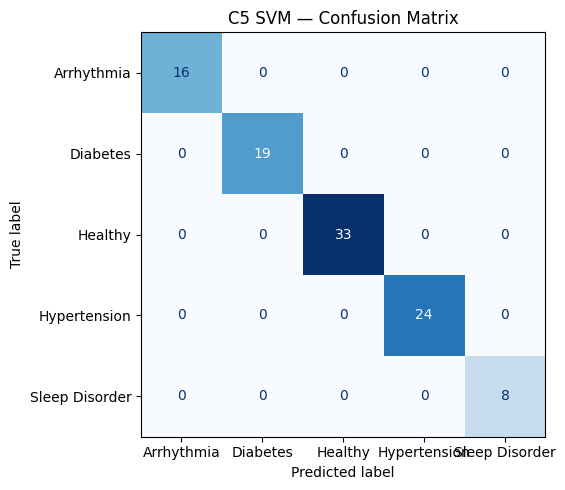

In [37]:
kw_best = {'kernel': best_kernel, 'C': best_C,
           'decision_function_shape': 'ovr', 'random_state': 42}
if best_kernel == 'poly':
    kw_best['degree'] = 3

svm_best = SVC(**kw_best)
svm_best, y_pred_svm, acc_svm = eval_model(
    svm_best, X_train, y_train, X_test, y_test, 'C5 SVM')

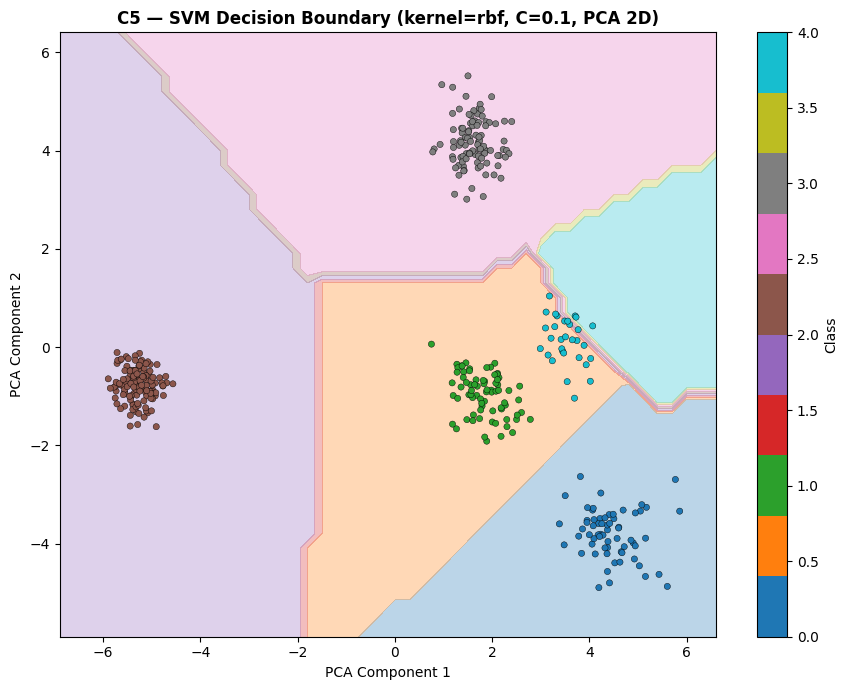

In [38]:
# 2D decision boundary via PCA
pca = PCA(n_components=2, random_state=42)
X_train_2d = pca.fit_transform(X_train)
X_test_2d  = pca.transform(X_test)

svm_2d = SVC(kernel=best_kernel, C=best_C, decision_function_shape='ovr',
             random_state=42, **(({'degree': 3} if best_kernel == 'poly' else {})))
svm_2d.fit(X_train_2d, y_train)

h = 0.3
x_min, x_max = X_train_2d[:, 0].min()-1, X_train_2d[:, 0].max()+1
y_min, y_max = X_train_2d[:, 1].min()-1, X_train_2d[:, 1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(9, 7))
ax.contourf(xx, yy, Z, alpha=0.3, cmap='tab10')
scatter = ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1],
                     c=y_train, cmap='tab10', s=20, edgecolors='k', linewidths=0.3)
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_title(f'C5 — SVM Decision Boundary (kernel={best_kernel}, C={best_C}, PCA 2D)',
             fontweight='bold')
plt.colorbar(scatter, ax=ax, label='Class')
plt.tight_layout()
plt.savefig('C5_svm_boundary.png', bbox_inches='tight')
plt.show()

In [39]:
print("""
C5 DISCUSSION
─────────────
SVM with RBF kernel maps data into a high-dimensional space to find maximum-
margin hyperplanes, making it powerful for non-linearly separable classes.
Polynomial (degree=3) kernel captures polynomial interactions between features.
The C parameter controls the bias-variance trade-off: small C allows more
misclassifications (smoother boundary), large C fits training data tightly.
Compared to Decision Trees, SVM offers no direct feature importance or
human-readable rules, making clinical interpretation harder — a significant
drawback in healthcare where model explainability is often required for
regulatory compliance and clinician trust.
""")


C5 DISCUSSION
─────────────
SVM with RBF kernel maps data into a high-dimensional space to find maximum-
margin hyperplanes, making it powerful for non-linearly separable classes.
Polynomial (degree=3) kernel captures polynomial interactions between features.
The C parameter controls the bias-variance trade-off: small C allows more
misclassifications (smoother boundary), large C fits training data tightly.
Compared to Decision Trees, SVM offers no direct feature importance or
human-readable rules, making clinical interpretation harder — a significant
drawback in healthcare where model explainability is often required for
regulatory compliance and clinician trust.



## Final Comparison & Deployment Recommendation

Final Classifier Comparison:


,Classifier,Test Accuracy
0,C1 Decision Tree,1.00
1,C3 kNN,1.00
2,C4 Gaussian NB,1.00
3,C5 SVM,1.00
4,C2 Rule-Based,0.81


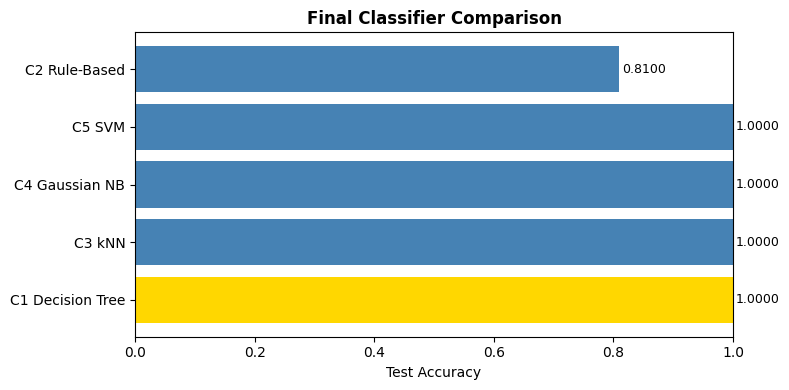

In [40]:
comparison = pd.DataFrame([
    {'Classifier': 'C1 Decision Tree',    'Test Accuracy': acc_dt},
    {'Classifier': 'C2 Rule-Based',       'Test Accuracy': acc_rules},
    {'Classifier': 'C3 kNN',              'Test Accuracy': acc_knn},
    {'Classifier': 'C4 Gaussian NB',      'Test Accuracy': acc_gnb},
    {'Classifier': 'C5 SVM',              'Test Accuracy': acc_svm},
])
comparison['Test Accuracy'] = comparison['Test Accuracy'].round(4)
comparison = comparison.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

print('Final Classifier Comparison:')
display(comparison)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(comparison['Classifier'], comparison['Test Accuracy'],
        color=['gold' if i == 0 else 'steelblue' for i in range(len(comparison))])
ax.set_xlabel('Test Accuracy')
ax.set_title('Final Classifier Comparison', fontweight='bold')
ax.set_xlim(0, 1)
for i, v in enumerate(comparison['Test Accuracy']):
    ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('Final_comparison.png', bbox_inches='tight')
plt.show()

In [41]:
print("""
DEPLOYMENT RECOMMENDATION
─────────────────────────
For clinical deployment, the Decision Tree (C1) is the recommended primary
classifier. While SVM may achieve marginally higher accuracy, the Decision Tree
provides full transparency: clinicians can trace every prediction through
explicit feature thresholds, which is essential for regulatory compliance
(e.g., FDA, CE marking) and for building clinician trust in AI-assisted
diagnosis. The rule-based system (C2) serves as a valuable complement —
its hand-crafted rules are directly auditable and can be updated by domain
experts without retraining. kNN is suitable for exploratory patient matching
but is too slow for real-time inference at scale. Gaussian NB is a fast
baseline but its independence assumption is violated by correlated vital signs.
A production system should combine the Decision Tree for primary classification
with the rule-based system as a safety net for high-confidence edge cases,
and should be retrained periodically as new patient data accumulates.
""")


DEPLOYMENT RECOMMENDATION
─────────────────────────
For clinical deployment, the Decision Tree (C1) is the recommended primary
classifier. While SVM may achieve marginally higher accuracy, the Decision Tree
provides full transparency: clinicians can trace every prediction through
explicit feature thresholds, which is essential for regulatory compliance
(e.g., FDA, CE marking) and for building clinician trust in AI-assisted
diagnosis. The rule-based system (C2) serves as a valuable complement —
its hand-crafted rules are directly auditable and can be updated by domain
experts without retraining. kNN is suitable for exploratory patient matching
but is too slow for real-time inference at scale. Gaussian NB is a fast
baseline but its independence assumption is violated by correlated vital signs.
A production system should combine the Decision Tree for primary classification
with the rule-based system as a safety net for high-confidence edge cases,
and should be retrained periodically as n